# Automated metrics — BriefMe `arg_summ` headings

**Entry point:** this notebook loads data, runs [briefme.metrics](../src/briefme/metrics.py), and plots **matplotlib** summaries and distributions.

**Setup:** same Python env as other notebooks (`pip install -e ".[dev]"` from repo root). Set `HUGGINGFACE_HUB_TOKEN` in `.env` for the dev split cells.

Below, each metric includes a short **what it catches / what it misses** note (north star §3A).

### Metric cheat sheet

- **ROUGE-1 / ROUGE-2 / ROUGE-L:** Catches lexical overlap between prediction and gold heading (**misses** synonymous rewrites that share few n-grams).
- **Exact match (after normalize):** Catches tiny formatting inconsistencies (**misses** any acceptable paraphrase).
- **Token F1:** Lexical overlap with repetition-aware bags (**misses** same as ROUGE-lite; interpretable per short strings).
- **chrF:** Character n-gram overlap — steadier with minor spelling/style drift (**misses** semantic mismatch with matching characters).

Corpus **chrF** uses SacreBLEU’s corpus CHRF; per-row chrF is sentence-level (can differ from corpus aggregation).

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

# override=True: re-running this cell reloads `.env` changes (dotenv normally does not
# overwrite vars already set in the kernel from a previous run).
load_dotenv(REPO_ROOT / ".env", override=True)

from briefme.data import SPLIT_DEV, load_arg_summ_split_streaming, materialize_head
from briefme.metrics import aggregate
from briefme.schema import SOURCE_COLUMN, TARGET_COLUMN

SUMMARY_KEYS = [
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "exact_match_rate",
    "token_f1_macro",
    "chrf_corpus",
]
SUMMARY_LABELS = ["R-1", "R-2", "R-L", "EM", "Tok-F1", "chrF"]


def cheap_baseline(passage: str, max_words: int = 14) -> str:
    """Uppercase-agnostic heading proxy: first `max_words` tokens of the passage."""
    words = passage.strip().split()
    return " ".join(words[:max_words])


def plot_summary_bars(ax, agg: dict, title: str) -> None:
    vals = [float(agg[k]) for k in SUMMARY_KEYS]
    x = np.arange(len(vals))
    ax.bar(x, vals, color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(SUMMARY_LABELS, rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score (0–1)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)


print("Repo:", REPO_ROOT)

Repo: /Users/naataaniitsosie/repos/cs474


## Toy sanity check

Two scenarios: **perfect** predictions vs **bad** predictions on the same references.

Good: {'rouge1_f': 1.0, 'rouge2_f': 1.0, 'rougeL_f': 1.0, 'exact_match_rate': 1.0, 'token_f1_macro': 1.0, 'chrf_corpus': 1.0}
Bad : {'rouge1_f': 0.0, 'rouge2_f': 0.0, 'rougeL_f': 0.0, 'exact_match_rate': 0.0, 'token_f1_macro': 0.0, 'chrf_corpus': 0.0594}


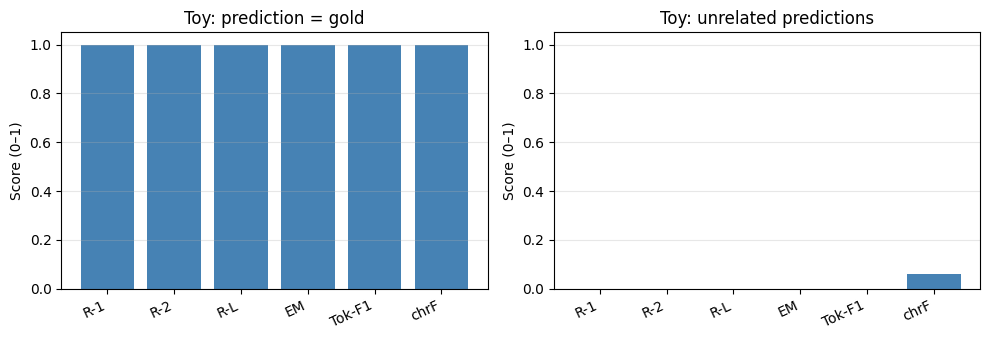

In [2]:
refs_toy = [
    "Summary judgment standard",
    "Discovery sanctions",
]
good_preds = list(refs_toy)
bad_preds = [
    "Weather report",
    "Totally unrelated heading",
]

agg_good = aggregate(good_preds, refs_toy)
agg_bad = aggregate(bad_preds, refs_toy)
print("Good:", {k: round(agg_good[k], 4) for k in SUMMARY_KEYS})
print("Bad :", {k: round(agg_bad[k], 4) for k in SUMMARY_KEYS})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_summary_bars(axes[0], agg_good, "Toy: prediction = gold")
plot_summary_bars(axes[1], agg_bad, "Toy: unrelated predictions")
plt.tight_layout()
plt.show()

## Dev split — gold vs cheap baseline

- **Gold-as-prediction:** sanity (scores should cluster high).
- **Baseline:** first ~14 tokens of the passage vs gold heading — expect lower overlap and useful spread for histograms.

In [ ]:
if not (os.getenv("HUGGINGFACE_HUB_TOKEN") or os.getenv("HF_TOKEN")):
    raise RuntimeError("Set HUGGINGFACE_HUB_TOKEN (or HF_TOKEN) in .env to load dev split.")

DEV_N = 80
dev_ds = materialize_head(load_arg_summ_split_streaming(SPLIT_DEV), DEV_N)
refs = [row[TARGET_COLUMN] for row in dev_ds]
gold_preds = list(refs)
base_preds = [cheap_baseline(row[SOURCE_COLUMN]) for row in dev_ds]

agg_gold = aggregate(gold_preds, refs)
agg_base = aggregate(base_preds, refs)

print("Gold-as-pred EM:", agg_gold["exact_match_rate"])
print("Baseline EM:", agg_base["exact_match_rate"])
print("Baseline mean ROUGE-L:", round(agg_base["rougeL_f"], 4))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_summary_bars(axes[0], agg_gold, f"Dev N={DEV_N}: gold heading as prediction")
plot_summary_bars(axes[1], agg_base, "Dev: cheap baseline (first tokens)")
plt.tight_layout()
plt.show()

In [ ]:
pe_g = agg_gold["per_example"]
pe_b = agg_base["per_example"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].hist(pe_g["rougeL_f"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[0, 0].hist(pe_b["rougeL_f"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[0, 0].set_title("Per-example ROUGE-L F1")
axes[0, 0].legend()

axes[0, 1].hist(pe_g["token_f1"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[0, 1].hist(pe_b["token_f1"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[0, 1].set_title("Per-example token F1")
axes[0, 1].legend()

axes[1, 0].hist(pe_g["chrf"], bins=15, alpha=0.7, label="gold pred", color="C0")
axes[1, 0].hist(pe_b["chrf"], bins=15, alpha=0.7, label="baseline", color="C1")
axes[1, 0].set_title("Per-example chrF (sentence)")
axes[1, 0].legend()

ax = axes[1, 1]
ax.scatter(pe_b["rougeL_f"], pe_b["token_f1"], alpha=0.6, s=22)
ax.set_xlabel("ROUGE-L")
ax.set_ylabel("Token F1")
ax.set_title("Baseline preds: ROUGE-L vs token F1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()